In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import time
import glob
import os

In [3]:
testDF = pd.read_csv('../SDCardOut/dos/26033020.CSV')
testDF

,timecode,seconds,lat,lat_dir,lon,lon_dir,sensor
0,260330_201540_000,72940.000,4159.9746,N,8739.3770,W,543
1,260330_201540_430,72940.430,4159.9746,N,8739.3770,W,497
2,260330_201540_529,72940.531,4159.9746,N,8739.3770,W,458
3,260330_201540_629,72940.633,4159.9746,N,8739.3770,W,427
4,260330_201540_729,72940.727,4159.9746,N,8739.3770,W,401
...,...,...,...,...,...,...,...
800,260330_201700_300,73020.297,4159.9844,N,8739.4414,W,347
801,260330_201700_400,73020.398,4159.9844,N,8739.4414,W,347
802,260330_201700_500,73020.500,4159.9844,N,8739.4414,W,346
803,260330_201700_600,73020.602,4159.9844,N,8739.4414,W,347


In [4]:
#get all unprocessed CSV files
files_CSV = glob.glob('../SDCardOut/dod/*.CSV', recursive=True)
#create output directory and path
output_dir = '../SDCardOut/dod/CSVtovoltage'
os.makedirs(output_dir, exist_ok=True)

for csv_file in files_CSV:
    print(f'Processing{csv_file}')

    #read file to create DF
    testDF = pd.read_csv(csv_file)

    #define arrays
    timecodeArr = np.array(testDF['timecode'])
    sensorArr = np.array(testDF['sensor'])
    voltageArr = sensorArr * 5/16383

    #use voltage array to define voltage DF 
    voltageDF = pd.DataFrame({'voltage': voltageArr})

    #ouput filename and path of voltage values
    output_name = os.path.basename(csv_file).replace('.CSV', '_tovoltage.csv')
    output_path = os.path.join(output_dir, output_name)
    voltageDF.to_csv(output_path, index=False)
    
    print(f'Done Processing {output_path}')

print("All files processed.")

Processing../SDCardOut/dod/26033025.CSV
Done Processing ../SDCardOut/dod/CSVtovoltage/26033025_tovoltage.csv
Processing../SDCardOut/dod/26033023.CSV
Done Processing ../SDCardOut/dod/CSVtovoltage/26033023_tovoltage.csv
Processing../SDCardOut/dod/26033022.CSV
Done Processing ../SDCardOut/dod/CSVtovoltage/26033022_tovoltage.csv
Processing../SDCardOut/dod/26033024.CSV
Done Processing ../SDCardOut/dod/CSVtovoltage/26033024_tovoltage.csv
Processing../SDCardOut/dod/26033021.CSV
Done Processing ../SDCardOut/dod/CSVtovoltage/26033021_tovoltage.csv
Processing../SDCardOut/dod/26033020.CSV
Done Processing ../SDCardOut/dod/CSVtovoltage/26033020_tovoltage.csv
All files processed.


In [5]:
timecodeArr = np.array(testDF['timecode'])
timecodeArr
len(timecodeArr)

805

In [6]:
sensorArr = np.array(testDF['sensor'])
sensorArr
len(sensorArr)

805

In [7]:
timeseries = np.arange(0,80.5,0.1)
import os
print(os.getcwd())

/home/jpaulson1/ALTrainSeismo/testsAndSuch


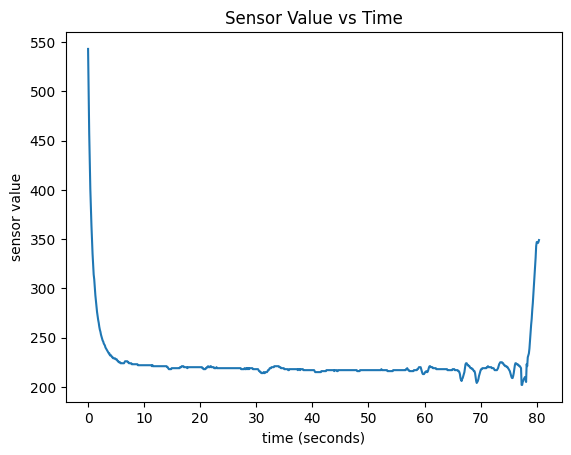

In [8]:
plt.plot(timeseries,sensorArr)
plt.title('Sensor Value vs Time')
plt.xlabel('time (seconds)')
plt.ylabel('sensor value')

plt.savefig('../SDCardOut/dod/graphs/sensor_plot.png', dpi=300, bbox_inches='tight')

In [9]:
voltageArr = sensorArr * 5/16383


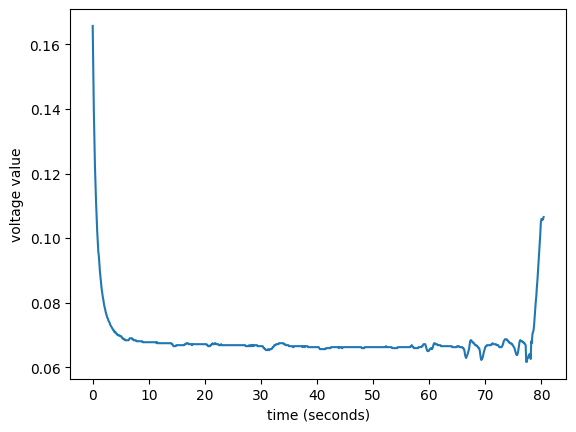

In [10]:
plt.plot(timeseries,voltageArr)
plt.xlabel('time (seconds)')
plt.ylabel('voltage value')

plt.savefig('../SDCardOut/dod/graphs/voltage_plot.png', dpi=300, bbox_inches='tight')

In [ ]:
#here include something that identifies what we should cut off from the beginning and end of the voltage graph. 
#produce xcut_min, xcut_max
#plot including plot.xlim(xcut_min, xcut_max)

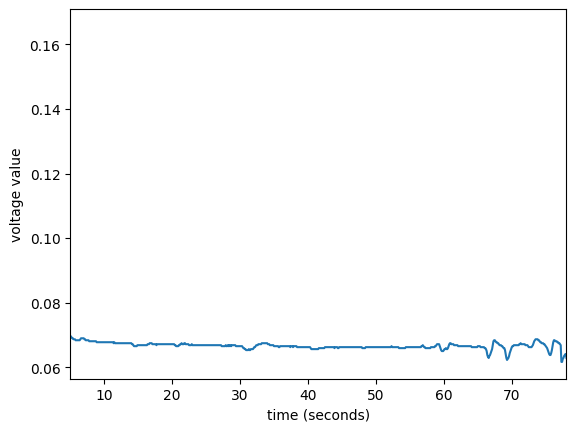

In [11]:
plt.plot(timeseries,voltageArr)
plt.xlabel('time (seconds)')
plt.ylabel('voltage value')
plt.xlim(5, 78)
#plot.xlim(xcut_min, xcut_max)

plt.savefig('../SDCardOut/dod/graphs/voltage_xcut_plot.png', dpi=300, bbox_inches='tight')

In [ ]:
#here include something that identifies what the cutoff voltage should be, distinguising signals from background noise 
#produce ycutoff and ymax
#option 1: produce a graph of only voltages below ycutoff ---> this is the background voltage  plot
#          produce a graph of only voltages above ycutoff ---> this is the events voltage plot
#option 1 is shown below
#option 2: produce a graph with a line representing ycutoff. I do not want to do this until I have a way to define cutoff voltage.


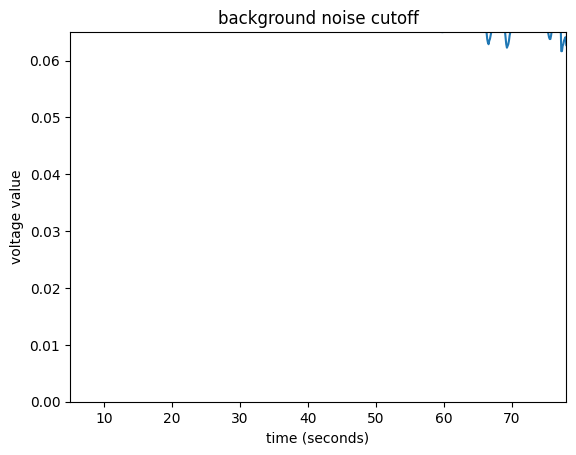

In [21]:
plt.plot(timeseries,voltageArr)
plt.xlim(5, 78)
plt.ylim(0, 0.065)
#plt.ylim(0, ycutoff)
plt.title('background noise cutoff')
plt.xlabel('time (seconds)')
plt.ylabel('voltage value')

plt.savefig('../SDCardOut/dod/graphs/background_voltage_cut_plot.png', dpi=300, bbox_inches='tight')

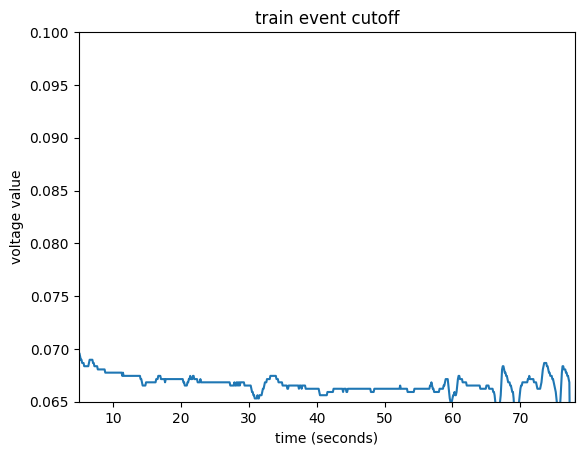

In [23]:
plt.plot(timeseries,voltageArr)
plt.xlim(5, 78)
plt.ylim(0.065, 0.1)
#plt.ylim(ycutoff, ymax 0.3)
plt.title('train event cutoff')
plt.xlabel('time (seconds)')
plt.ylabel('voltage value')

plt.savefig('../SDCardOut/dod/graphs/events_voltage_cut_plot.png', dpi=300, bbox_inches='tight')

In [14]:
freqpsd10,powpsd10 = sp.signal.welch(sensorArr,fs=10,nperseg=10)
freqpsd50,powpsd50 = sp.signal.welch(sensorArr,fs=10,nperseg=50)
freqpsd100,powpsd100 = sp.signal.welch(sensorArr,fs=10,nperseg=100)
freqpsd500,powpsd500 = sp.signal.welch(sensorArr,fs=10,nperseg=500)

[]

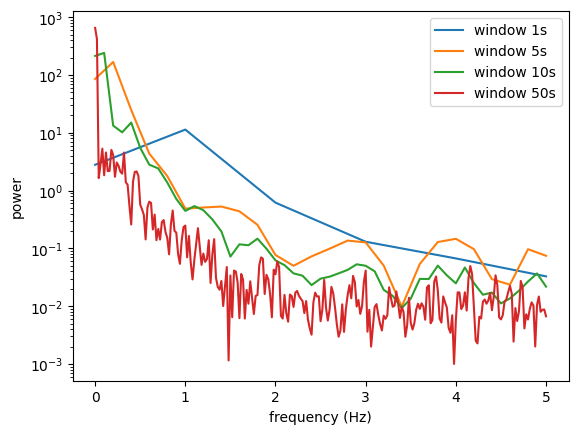

In [15]:
plt.plot(freqpsd10,powpsd10,label="window 1s")
plt.plot(freqpsd50,powpsd50,label="window 5s")
plt.plot(freqpsd100,powpsd100,label="window 10s")
plt.plot(freqpsd500,powpsd500,label="window 50s")
plt.xlabel('frequency (Hz)')
plt.ylabel("power")
plt.legend()
plt.semilogy()

In [16]:
#ok